In [17]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
from astropy.coordinates import angular_separation
import scienceplots
from os.path import exists
import seaborn as sns
import matplotlib as mpl

from astropy.cosmology import FlatLambdaCDM

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

SPEED_OF_LIGHT = 299_792.458

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
def interp_dist2redshift(dist, Om0=0.3, zmin_interp=1e-6,
                         zmax_interp=0.1, npoints_interp=1000):
    cosmo = FlatLambdaCDM(H0=100, Om0=Om0)
    z_grid = np.linspace(zmin_interp, zmax_interp, npoints_interp)
    dist_grid = cosmo.comoving_distance(z_grid).value

    return np.exp(np.interp(np.log(dist), np.log(dist_grid), np.log(z_grid),
                            left=np.nan, right=np.nan))

In [ ]:
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TF-distances.hdf5"

loader = csiborgtools.flow.DataLoader("Carrick2015", [0], "CF4_TFR_i", fpath, paths, ksmooth=0, )

angdist = angular_separation(
    np.deg2rad(loader.cat["RA"]), np.deg2rad(loader.cat["DEC"]),
    np.deg2rad(csiborgtools.clusters["Virgo"].spherical_pos[1]),
    np.deg2rad(csiborgtools.clusters["Virgo"].spherical_pos[2]))
k = np.argmin(angdist)
print([loader.cat["RA"][k], loader.cat["DEC"][k]])
print(csiborgtools.clusters["Virgo"].spherical_pos[1:])
print(csiborgtools.clusters["Virgo"].spherical_pos[0])


2025-02-25 03:17:03   reading the catalogue,


2025-02-25 03:17:03   reading the interpolated field.
2025-02-25 03:17:12   calculating the radial velocity.
[186.63449, 12.6106]
[186.75        12.71666667]
12.045


In [79]:
r = csiborgtools.clusters["Virgo"].cartesian_pos(100) - 50
r /= np.linalg.norm(r)
r

array([-0.96870904, -0.11465427,  0.22012997])

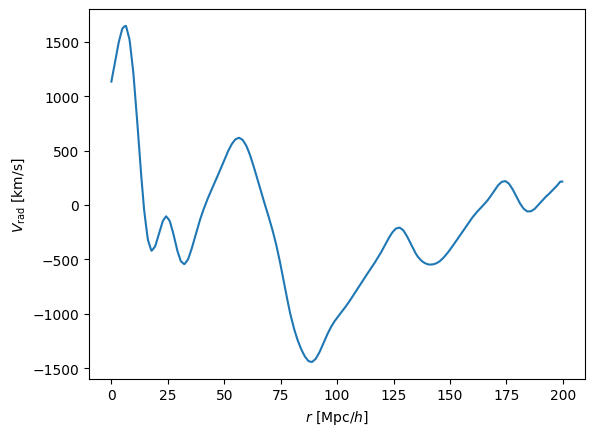

In [91]:
r = loader.rdist
vrad = loader.los_radial_velocity[0, k, :]

plt.figure()
plt.plot(r, vrad)
plt.xlabel(r"$r ~ [\mathrm{Mpc} / h]$")
plt.ylabel(r"$V_{\mathrm{rad}} ~ [\mathrm{km/s}]$")
plt.show()

In [92]:
X = np.vstack([r, vrad]).T
np.savetxt("virgo_los.txt", X)